k=1  inertia=5498.79  silhouette=nan  db=nan
k=2  inertia=4273.61  silhouette=0.1952  db=1.8444
k=3  inertia=3821.98  silhouette=0.1458  db=1.9446
k=4  inertia=3524.63  silhouette=0.1291  db=2.1544
k=5  inertia=3318.20  silhouette=0.1182  db=2.0052
k=6  inertia=3185.55  silhouette=0.1106  db=2.0784
k=7  inertia=3064.14  silhouette=0.1123  db=2.0980
k=8  inertia=2950.75  silhouette=0.1107  db=2.1437
k=9  inertia=2852.75  silhouette=0.1089  db=2.1425
k=10  inertia=2771.19  silhouette=0.1096  db=2.0931
        inertia  silhouette  davies_bouldin
k                                          
1   5498.794000         NaN             NaN
2   4273.614698    0.195249        1.844355
3   3821.980601    0.145779        1.944570
4   3524.626171    0.129050        2.154442
5   3318.201856    0.118231        2.005200
6   3185.552199    0.110636        2.078398
7   3064.138095    0.112267        2.098048
8   2950.746972    0.110734        2.143661
9   2852.748650    0.108903        2.142536
10  2771.18

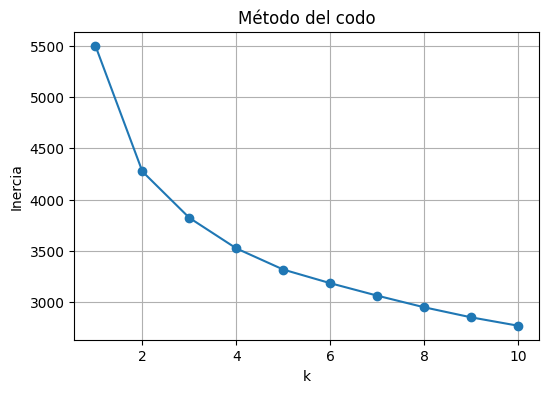

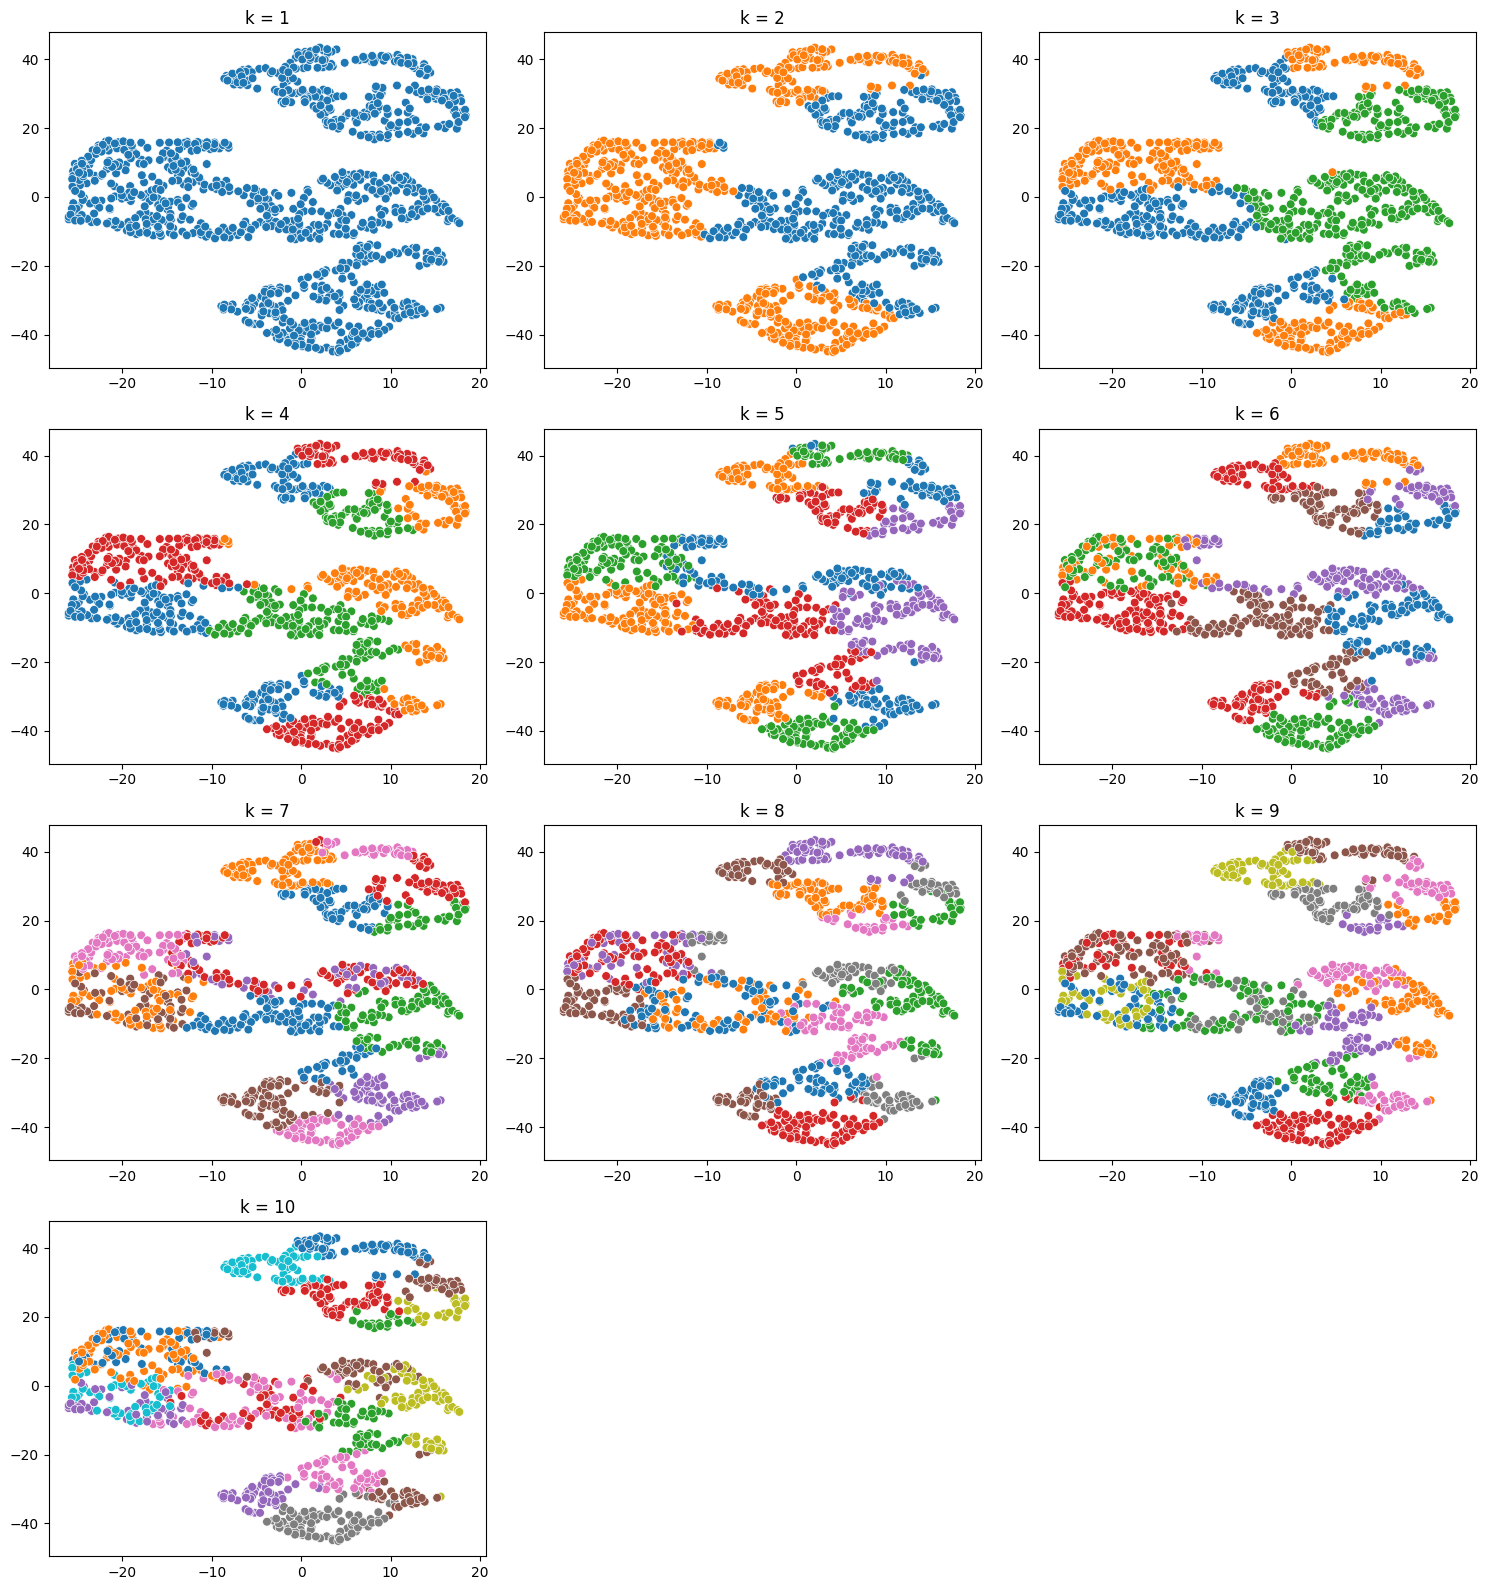

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Cargar datos
df = pd.read_csv("data//clientes.csv")

# Columnas
num_cols = ["Total", "Unit price", "Rating", "Quantity"]
num_cols_min = ["Total", "Rating", "Quantity"]
cat_cols = ["Customer type", "Gender", "Product line", "Payment"]
df = df[num_cols_min + cat_cols]


# Preprocesador
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols_min),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

# Transformar datos (fit_transform una sola vez)
X_transformed = preprocessor.fit_transform(df)

# Opcional: PCA previo para acelerar t-SNE
pca_pre = PCA(n_components=3, random_state=42)
X_pca3 = pca_pre.fit_transform(X_transformed)

ks = [1,2,3,4,5,6,7,8,9,10]
results = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_transformed)
    inertia = km.inertia_
    sil = silhouette_score(X_transformed, labels) if k > 1 else np.nan
    db = davies_bouldin_score(X_transformed, labels) if k > 1 else np.nan
    results.append({"k": k, "inertia": inertia, "silhouette": sil, "davies_bouldin": db})
    print(f"k={k}  inertia={inertia:.2f}  silhouette={sil:.4f}  db={db:.4f}")

# DataFrame de métricas
metrics_df = pd.DataFrame(results).set_index("k")
print(metrics_df)

# Gráfica de inercia (codo)
plt.figure(figsize=(6,4))
plt.plot(metrics_df.index, metrics_df["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True)
plt.show()

# Generar t-SNE y graficar subplots para cada k
# Usar PCA previo para acelerar t-SNE
X_for_tsne = X_pca3  # o X_transformed si prefieres
tsne = TSNE(n_components=2, perplexity=40, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_for_tsne)

ncols = 3
nrows = int(np.ceil(len(ks)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, k in zip(axes, ks):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_transformed)
    labels = km.labels_
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette="tab10", s=40, ax=ax, legend=False)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Ocultar ejes sobrantes
for ax in axes[len(ks):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
